In [1]:
import numpy as np
import os
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset, Dataset
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from typing import List, TypeVar, Any, Optional
Tensor = TypeVar('torch.tensor')

In [62]:
EPS = 1e-8

class ChannelScaler:
    def __init__(self, num_channels: int = 3):
        self.num_channels = num_channels
        self.sum = torch.zeros(num_channels, dtype=torch.float32)  
        self.sum_sq = torch.zeros(num_channels, dtype=torch.float32)  
        self.total_count = 0  
        self.mean = torch.zeros(num_channels, dtype=torch.float32)
        self.std = torch.ones(num_channels, dtype=torch.float32)
    
    def partial_fit(self, data: torch.Tensor):
        assert data.dim() == 3 and data.shape[-1] == self.num_channels
        B, T, C = data.shape
        data_flat = data.reshape(-1, C)  # [B*T, C]
        # 累计总和、平方和、总样本数
        self.sum += data_flat.sum(dim=0)  # [C]：每个通道的累计和
        self.sum_sq += (data_flat ** 2).sum(dim=0)  # [C]：每个通道的累计平方和
        self.total_count += data_flat.shape[0]  # 累计总时间步数量
    
    def finalize(self):
        self.mean = self.sum / self.total_count
        var = (self.sum_sq / self.total_count) - (self.mean ** 2)
        self.std = torch.sqrt(var.clamp(min=EPS)) 
    
    def transform(self, data: torch.Tensor) -> torch.Tensor:
        return (data - self.mean.to(data.device)) / self.std.to(data.device)
    
    def inverse_transform(self, data: torch.Tensor) -> torch.Tensor:
        return data * self.std.to(data.device) + self.mean.to(data.device)

class DummyUAVDataset(Dataset):
    def __init__(self, window_size=30, step_size=3, batch_size=8, mode='1-hover', phase='2_6'):
        self.window_size = window_size

        base_data_path = os.path.join(os.getcwd(), '..', '..', 'data', 'Dpro', mode)
        columns = ['accelerometer_m_s2[0]', 'accelerometer_m_s2[1]', 'accelerometer_m_s2[2]']
        # columns = ['gyro_rad[0]', 'gyro_rad[1]', 'gyro_rad[2]', 'accelerometer_m_s2[0]', 'accelerometer_m_s2[1]', 'accelerometer_m_s2[2]', 'magnetometer_ga[0]', 'magnetometer_ga[1]', 'magnetometer_ga[2]']
        sim_data = pd.read_csv(base_data_path + f'/all_sycn_sim_data_mode{phase}.csv', usecols=columns).to_numpy()
        raw_data = pd.read_csv(base_data_path + f'/all_sycn_raw_data_mode{phase}.csv', usecols=columns).to_numpy()
        err_data = pd.read_csv(base_data_path + f'/all_sycn_err_data_mode{phase}.csv', usecols=columns).to_numpy()
        self.total_seq_length = sim_data.shape[0] // 2
        # print(f'sim_data:{sim_data.shape} raw_data:{raw_data.shape} err_data:{err_data.shape}')

        self.dataset_x  = self.data_to_model(data=sim_data, sequence_length=window_size, step_size=step_size)
        self.dataset_y  = self.data_to_model(data=raw_data, sequence_length=window_size, step_size=step_size)
        self.dataset_e = self.data_to_model(data=err_data, sequence_length=window_size, step_size=step_size)
        print(f'dataset_x:{self.dataset_x.shape}')

        dataset = TensorDataset(self.dataset_x, self.dataset_y, self.dataset_e)
        self.dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, drop_last=True)
        
    def data_to_model(self, data, sequence_length=120, step_size=25):
        data = torch.tensor(data, dtype=float)
        sequences = []
        N = data.shape[0]
        
        for start_idx in range(0, N - sequence_length + 1, step_size):
            sequence = data[start_idx:start_idx + sequence_length]
            sequences.append(sequence)
        
        sequences = torch.stack(sequences)
        return sequences

# 1-hover 2-hover-accx-flag3-params03 4-hover-motor4-flag4-params085 5-hover-motor34-flag4-params08085 6-hover-motor234-flag4-params07508085
window_size, step_size, batch_size = 75, 25, 8
datasetuav = DummyUAVDataset(step_size=step_size, window_size=window_size, batch_size=batch_size, mode='1-hover', phase='2_6')

dataset_x:torch.Size([460, 75, 3])


In [63]:
from abc import abstractmethod

class BaseVAE(nn.Module):
    
    def __init__(self) -> None:
        super(BaseVAE, self).__init__()

    def encode(self, input: Tensor) -> List[Tensor]:
        raise NotImplementedError

    def decode(self, input: Tensor) -> Any:
        raise NotImplementedError

    def sample(self, batch_size:int, current_device: int, **kwargs) -> Tensor:
        raise NotImplementedError

    def generate(self, x: Tensor, **kwargs) -> Tensor:
        raise NotImplementedError

    @abstractmethod
    def forward(self, *inputs: Tensor) -> Tensor:
        pass

    @abstractmethod
    def loss_function(self, *inputs: Any, **kwargs) -> Tensor:
        pass

In [64]:
class GlobalFeatureRegister(nn.Module): 
    def __init__(self, 
                 init_capacity: int = 500,  
                 latent_dim: int = 256,    
                 seq_len: int = 64,         
                 cos_sim_threshold: float = 0.95, 
                 device: str = 'cuda'):
        super().__init__()
        self.latent_dim = latent_dim
        self.seq_len = seq_len
        self.cos_sim_threshold = cos_sim_threshold
        self.device = device


        self.register_buffer('features', torch.zeros((init_capacity, seq_len, latent_dim), device=device))
        self.register_buffer('pos_trend', torch.zeros((init_capacity, 1), device=device))
        self.register_buffer('stat_feat', torch.zeros((init_capacity, 2*latent_dim), device=device))
        self.register_buffer('cur_count', torch.tensor(0, device=device, dtype=torch.long))
        self.register_buffer('init_capacity', torch.tensor(init_capacity, device=device, dtype=torch.long))

    def _calc_pos_trend_feat(self, feat: Tensor):
        # 1. 时序波动度：每个latent维度在seq维度的方差 → 均值（体现特征随位置的波动）
        seq_var_per_dim = torch.var(feat, dim=0)  # [latent_dim] → 每个维度的时序方差
        pos_volatility = torch.mean(seq_var_per_dim).item()  # 全局时序波动度
        
        # 2. 全局均值：特征所有维度+所有时序位置的均值（体现特征整体水平）
        global_mean = torch.mean(feat).item()
        
        return pos_volatility, global_mean

    def _calc_stat_feat(self, feat: Tensor) -> Tensor:
        # feat: [seq_len, latent_dim] → [2*latent_dim]
        mean = feat.mean(dim=0)  # [latent_dim]
        std = feat.std(dim=0)    # [latent_dim]
        return torch.cat([mean, std], dim=0)

    def _calc_cos_sim(self, feat1: Tensor, feat2: Tensor) -> float:
        # feat1/feat2: [seq_len, latent_dim]
        flat1 = feat1.flatten()
        flat2 = feat2.flatten()
        return F.cosine_similarity(flat1.unsqueeze(0), flat2.unsqueeze(0), dim=1).item()

    def _dynamic_expand(self):
        current_cap = self.features.shape[0]
        new_cap = current_cap * 2
        new_feat = torch.zeros((new_cap, self.seq_len, self.latent_dim), device=self.device)
        new_feat[:current_cap] = self.features
        self.features = new_feat
        new_trend = torch.zeros((new_cap, 3), device=self.device)
        new_trend[:current_cap] = self.pos_trend
        self.pos_trend = new_trend
        new_stat = torch.zeros((new_cap, 2*self.latent_dim), device=self.device)
        new_stat[:current_cap] = self.stat_feat
        self.stat_feat = new_stat

    def update(self, new_features: Tensor, start_pos: Tensor):
        """
        new_features: [B, seq_len, latent_dim] → 编码器输出特征
        start_pos: [B] → 每个样本的时序起始位置（如第100帧、第200帧）
        """
        B, N, D = new_features.shape
        assert N == self.seq_len and D == self.latent_dim, "特征维度不匹配"

        for b in range(B):
            feat = new_features[b]  # [seq_len, latent_dim]
            pos = start_pos[b].item()  # 时序起始位置

            # 1. 计算当前特征的趋势+统计特征
            # pos_volatility, global_mean = self._calc_pos_trend_feat(feat)
            stat = self._calc_stat_feat(feat)  # [2*latent_dim]

            # 2. 特征筛选：与已有特征对比余弦相似度
            is_duplicate = False
            if self.cur_count > 0:
                for i in range(self.cur_count):
                    existing_feat = self.features[i]
                    sim = self._calc_cos_sim(feat, existing_feat)
                    if sim >= self.cos_sim_threshold:
                        is_duplicate = True
                        break

            # 3. 非重复特征则保留
            if not is_duplicate:
                # 动态扩容检查
                if self.cur_count >= self.features.shape[0]:
                    self._dynamic_expand()

                self.features[self.cur_count] = feat
                self.pos_trend[self.cur_count] = torch.tensor([pos], device=self.device)
                # 存入统计特征
                self.stat_feat[self.cur_count] = stat
                # 更新计数
                self.cur_count += 1

    def sample_by_trend(self, target_start_pos: Tensor, target_seq_len: int) -> Tensor:
        """
        按位置趋势采样（时序对齐）
        target_start_pos: [B] → 每个样本的目标起始位置
        target_seq_len: 目标时序长度
        return: [B, target_seq_len, latent_dim] → 对齐的特征
        """
        B = target_start_pos.shape[0]
        sampled_feats = []

        for b in range(B):
            pos = target_start_pos[b].item()
            if self.cur_count == 0:
                # 无特征时随机初始化（仅兜底）
                feat = torch.randn((self.seq_len, self.latent_dim), device=self.device)
            else:
                # 1. 计算目标位置与已有特征的位置+趋势相似度
                pos_diff = torch.abs(self.pos_trend[:self.cur_count, 0] - pos)  # 原始位置差
                vol_diff = torch.abs(self.pos_trend[:self.cur_count, 1] - self.pos_trend[:self.cur_count, 1].mean())  # 波动度差
                mean_diff = torch.abs(self.pos_trend[:self.cur_count, 2] - self.pos_trend[:self.cur_count, 2].mean())  # 全局均值差

                # 2. 综合相似度得分（权重可调）
                score = 0.7 * (1 / (pos_diff + 1e-8)) + 0.15 * (1 / (vol_diff + 1e-8)) + 0.15 * (1 / (mean_diff + 1e-8))
                best_idx = torch.argmax(score)  # 最匹配的特征索引

                # 3. 获取最匹配的特征
                feat = self.features[best_idx]

            # 4. 裁剪/补零到目标长度（保持时序趋势）
            if target_seq_len < self.seq_len:
                feat = feat[:target_seq_len]
            else:
                # 补零（按最后一帧趋势补）
                pad_len = target_seq_len - self.seq_len
                last_trend = self.pos_trend[best_idx, 1].item() if self.cur_count > 0 else 0.0
                pad_feat = feat[-1:] + torch.arange(pad_len, device=self.device).float().unsqueeze(1) * last_trend * 0.1
                feat = torch.cat([feat, pad_feat], dim=0)

            sampled_feats.append(feat)

        return torch.stack(sampled_feats, dim=0)  # [B, target_seq_len, latent_dim]

    def reset(self):
        """重置寄存器"""
        self.features.zero_()
        self.pos_trend.zero_()
        self.stat_feat.zero_()
        self.cur_count = 0

class VectorQuantizer(nn.Module):
    def __init__(self,
                 num_embeddings: int,  # K
                 embedding_dim: int,   # D
                 beta: float = 0.25):
        super(VectorQuantizer, self).__init__()
        self.K = num_embeddings
        self.D = embedding_dim
        self.beta = beta

        self.embedding = nn.Embedding(self.K, self.D)
        self.embedding.weight.data.uniform_(-1 / self.K, 1 / self.K)
    
    def get_codebook_indices(self, latents: Tensor) -> Tensor:
        latents = latents.permute(0, 2, 1)  # [B, D, N]
        flat_latents = latents.reshape(-1, self.D)  # [B*N, D]

        dist = torch.sum(flat_latents ** 2, dim=1, keepdim=True) + \
               torch.sum(self.embedding.weight ** 2, dim=1) - \
               2 * torch.matmul(flat_latents, self.embedding.weight.t())  # [B*N, K]

        encoding_inds = torch.argmin(dist, dim=1)  # [B*N]
        encoding_inds = encoding_inds.view(latents.shape[0], latents.shape[2])  # [B, N]

        return encoding_inds

    def forward(self, latents: Tensor):
        latents = latents.permute(0, 2, 1)  # [B x N x D] -> [B x D x N]
        latents_shape = latents.shape
        flat_latents = latents.reshape(-1, self.D)  # [B*N x D]

        dist = torch.sum(flat_latents ** 2, dim=1, keepdim=True) + \
               torch.sum(self.embedding.weight ** 2, dim=1) - \
               2 * torch.matmul(flat_latents, self.embedding.weight.t())  # [B*N x K]

        encoding_inds = torch.argmin(dist, dim=1).unsqueeze(1)  # [B*N, 1]

        device = latents.device
        encoding_one_hot = torch.zeros(encoding_inds.size(0), self.K, device=device)
        encoding_one_hot.scatter_(1, encoding_inds, 1)  # [B*N x K]

        quantized_latents = torch.matmul(encoding_one_hot, self.embedding.weight)  # [B*N, D]
        quantized_latents = quantized_latents.view(latents_shape)  # [B x D x N]

        commitment_loss = F.mse_loss(quantized_latents.detach(), latents)
        embedding_loss = F.mse_loss(quantized_latents, latents.detach())
        vq_loss = commitment_loss * self.beta + embedding_loss

        quantized_latents = latents + (quantized_latents - latents).detach()

        return quantized_latents.permute(0, 2, 1), vq_loss  # [B x N x D]

class VQVAE(BaseVAE):
    def __init__(self,
                 in_channels: int, 
                 embedding_dim: int,
                 num_embeddings: int,
                 hidden_dims: List = None,
                 beta: float = 0.25,
                 seq_len: int = 64,
                 register_init_capacity: int = 500,
                 register_cos_threshold: float = 0.95,
                 device: str = 'cuda',
                 **kwargs) -> None:
        super(VQVAE, self).__init__()

        self.embedding_dim = embedding_dim
        self.num_embeddings = num_embeddings
        self.seq_len = seq_len
        self.beta = beta
        self.device = device

        if hidden_dims is None:
            hidden_dims = [128, 256]
        self.hidden_dims = hidden_dims

        self.lstm_layers = nn.ModuleList()
        input_dim = in_channels  
        for hidden_dim in hidden_dims:
            self.lstm_layers.append(nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, batch_first=True))
            input_dim = hidden_dim  

        self.feature_register = GlobalFeatureRegister(
            init_capacity=register_init_capacity,
            latent_dim=hidden_dims[-1],
            seq_len=seq_len,
            cos_sim_threshold=register_cos_threshold,
            device=device
        )

        self.vq_layer = VectorQuantizer(num_embeddings, embedding_dim, beta)

        self.lstm_decoders = nn.ModuleList()
        input_dim = hidden_dims[-1]
        for h_dim in reversed(hidden_dims):
            self.lstm_decoders.append(nn.LSTM(input_dim, h_dim, batch_first=True))
            input_dim = h_dim

        self.output_lstm = nn.LSTM(input_size=hidden_dims[0], hidden_size=in_channels, batch_first=True)

    def encode(self, input: Tensor) -> Tensor:
        result = input
        for lstm in self.lstm_layers:
            result, _ = lstm(result) 
        return result 

    def decode(self, z: Tensor) -> Tensor:
        result = z
        for lstm in self.lstm_decoders:
            result, _ = lstm(result)  
        result, _ = self.output_lstm(result) 
        return result

    def forward(self, input: Tensor, start_pos: Tensor, **kwargs):
        """
        start_pos: [B] → 每个样本的时序起始位置（关键：用于寄存器趋势记录）
        """
        # 1. 编码+更新寄存器（训练阶段）
        encoding = self.encode(input)
        if self.training:
            self.feature_register.update(new_features=encoding, start_pos=start_pos)

        # 2. 重建任务
        quantized_inputs, vq_loss = self.vq_layer(encoding)
        recon_err = self.decode(quantized_inputs)
        
        recons_loss = F.mse_loss(recon_err, input)
        w_loss_recon = self.wasserstein_loss(input, recon_err)

        # 4. 总损失
        total_loss = recons_loss + vq_loss + w_loss_recon 

        loss_dict = {
            'Loss': total_loss,
            'Recon_Loss': recons_loss,
            'VQ_Loss': vq_loss,
            'W_Loss_Recon': w_loss_recon,
        }

        return recon_err, loss_dict

    @torch.no_grad()
    def generate(self, 
                 batch_size: int, 
                 seq_len: Optional[int] = None, 
                 device: str = 'cuda', 
                 use_eval: bool = True,
                 history_err: Optional[Tensor] = None,
                 target_start_pos: Optional[Tensor] = None,  # 目标起始位置（时序对齐）
                 noise_scale: float = 0.01) -> Tensor:
        
        if use_eval:
            self.eval()
        
        seq_len = seq_len if seq_len is not None else self.seq_len

        # 分支1：优先使用寄存器（按位置趋势采样）
        if target_start_pos is not None and self.feature_register.cur_count > 0:
            sampled_feat = self.feature_register.sample_by_trend(
                target_start_pos=target_start_pos,
                target_seq_len=seq_len
            )
            noise = torch.randn_like(sampled_feat) * noise_scale
            if self.feature_register.cur_count > 0:
                trend = self.feature_register.pos_trend[:, 1].mean().item()
                noise = noise * (1 - abs(trend) * 0.5)  # 趋势越陡，噪声越小
            noisy_feat = sampled_feat + noise
            quantized_latent, _ = self.vq_layer(noisy_feat)
            gen_err = self.decode(quantized_latent)
        
        elif history_err is not None:
            history_latent = self.encode(history_err)  
            noise = torch.randn_like(history_latent) * noise_scale
            noisy_latent = history_latent + noise
            quantized_latent, _ = self.vq_layer(noisy_latent)
            gen_err = self.decode(quantized_latent)
        
        else:
            codebook_indices = torch.randint(
                low=0, high=self.num_embeddings,
                size=(batch_size, seq_len),
                device=device
            )
            quantized_latents = self.vq_layer.embedding(codebook_indices)
            gen_err = self.decode(quantized_latents)
        
        if use_eval and self.training:
            self.train()

        return gen_err

    def wasserstein_loss(self, x, recon_x, std_weight=1):
        mean_x = torch.mean(x, dim=(0, 1)) 
        std_x = torch.std(x, dim=(0, 1))   
        mean_recon_x = torch.mean(recon_x, dim=(0, 1)) 
        std_recon_x = torch.std(recon_x, dim=(0, 1))  
        loss = torch.mean(torch.abs(mean_x - mean_recon_x) + std_weight * torch.abs(std_x - std_recon_x)) 
        return loss

In [68]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
'''
# print(device)
# print(torch.__version__)                # 查看pytorch安装的版本号
# print(torch.cuda.is_available())        # 查看cuda是否可用。True为可用，即是gpu版本pytorch
# print(torch.cuda.get_device_name(0))    # 返回GPU型号
# print(torch.cuda.device_count())        # 返回可以用的cuda（GPU）数量，0代表一个
# print(torch.version.cuda) 
'''
vae = VQVAE(
        in_channels=3,
        embedding_dim=128,
        num_embeddings=512,
        hidden_dims=[64, 128],
        seq_len=window_size,
        register_init_capacity=5,
        register_cos_threshold=0.95,
        device=device
    ).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)
# print(vae)

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
num_epochs = 250
dataloader = datasetuav.dataloader

In [69]:
def train_vae(vae, train_loader, optimizer, device, epochs=50):
    vae.train()
    epoch_losses = []
    total_seq_length = datasetuav.total_seq_length
    valid_start_max = total_seq_length - vae.seq_len 
    for epoch in range(epochs):
        total_loss = 0.0
        total_recon_loss = 0.0
        total_w_recon_loss = 0.0
        
        for batch_idx, (_, _, err) in enumerate(train_loader):
            B, N, C = err.shape  
            err = err.to(device, dtype=torch.float32) 
            start_pos = torch.arange(batch_idx*B, (batch_idx+1)*B, device=device) % (valid_start_max + 1)
            recon_err, loss_dict = vae(
                err, 
                start_pos=start_pos
            )
            
            optimizer.zero_grad()
            loss_dict['Loss'].backward()  
            torch.nn.utils.clip_grad_norm_(vae.parameters(), max_norm=1.0)  
            optimizer.step()
            
            total_loss += loss_dict['Loss'].item() * err.size(0)
            total_recon_loss += loss_dict['Recon_Loss'].item() * err.size(0)
            total_w_recon_loss += loss_dict['W_Loss_Recon'].item() * err.size(0)
        
        avg_loss = total_loss / len(train_loader.dataset)
        avg_recon_loss = total_recon_loss / len(train_loader.dataset)
        avg_w_recon_loss = total_w_recon_loss / len(train_loader.dataset)
        
        epoch_losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Total Loss: {avg_loss:.6f} | "
              f"Recon Loss: {avg_recon_loss:.6f} | "
              f"W_Recon Loss: {avg_w_recon_loss:.6f}")
        
        # if (epoch+1) % 10 == 0:
        #     torch.save(vae.state_dict(), f"vqvae_gen_trained_epoch_{epoch+1}.pth")
    
    plt.figure(figsize=(4, 4))
    plt.plot(epoch_losses, label='Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('VAE Training Loss Curve')
    plt.legend()
    plt.show()

train_vae(vae, dataloader, optimizer, device, epochs=num_epochs)

Epoch 1/250 | Total Loss: 0.476183 | Recon Loss: 0.117941 | W_Recon Loss: 0.357630
Epoch 2/250 | Total Loss: 0.467544 | Recon Loss: 0.117043 | W_Recon Loss: 0.350439
Epoch 3/250 | Total Loss: 0.466143 | Recon Loss: 0.116994 | W_Recon Loss: 0.348840
Epoch 4/250 | Total Loss: 0.513715 | Recon Loss: 0.159387 | W_Recon Loss: 0.269522
Epoch 5/250 | Total Loss: 0.437363 | Recon Loss: 0.167661 | W_Recon Loss: 0.229951
Epoch 6/250 | Total Loss: 0.409074 | Recon Loss: 0.161123 | W_Recon Loss: 0.237590
Epoch 7/250 | Total Loss: 0.344964 | Recon Loss: 0.177253 | W_Recon Loss: 0.163573
Epoch 8/250 | Total Loss: 0.308141 | Recon Loss: 0.184192 | W_Recon Loss: 0.122866
Epoch 9/250 | Total Loss: 0.297349 | Recon Loss: 0.187190 | W_Recon Loss: 0.109525
Epoch 10/250 | Total Loss: 0.295172 | Recon Loss: 0.187653 | W_Recon Loss: 0.106993
Epoch 11/250 | Total Loss: 0.294145 | Recon Loss: 0.188225 | W_Recon Loss: 0.105341
Epoch 12/250 | Total Loss: 0.293630 | Recon Loss: 0.190097 | W_Recon Loss: 0.103067
E

KeyboardInterrupt: 

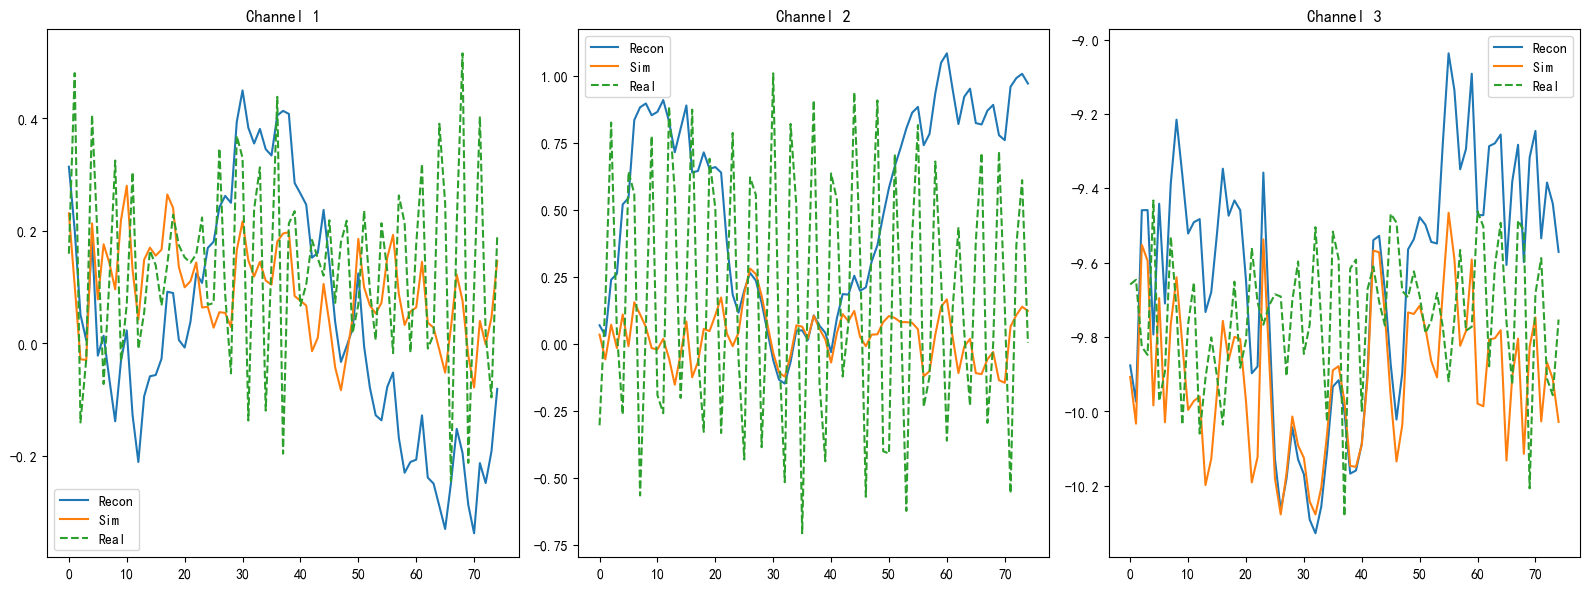

✅ 测试集评估指标:
    MSE: 2.653767
    MAE: 3.666651
    RMSE: 4.586511
    R² Score: -37.463919
    Wasserstein Distance: 0.332516


In [70]:
from scipy.stats import wasserstein_distance
from sklearn.metrics import r2_score

def calculate_wasserstein_distance(pred, true):
    """计算Wasserstein距离（Earth Mover's Distance）"""
    wasserstein_dist = 0
    D = pred.shape[1]  # 特征数
    
    for d in range(D):
        pred_data = pred[:, d].cpu().numpy()
        true_data = true[:, d].cpu().numpy()
        # 计算单特征的Wasserstein距离
        wasserstein_dist += wasserstein_distance(pred_data, true_data)
    
    return wasserstein_dist / D  # 返回所有特征的平均距离

def test_vae(vae, test_loader, device, look_id=4, tid=5, target_start=False):
    vae.eval()
    metrics = {
        'mse': 0.0,
        'mae': 0.0,
        'rmse': 0.0,
        'r2': 0.0,
        'wasserstein': 0.0,
    }
    count = 0
    total_samples = 0
    predictions = []
    true_data = []
    origin_sim = []

    total_seq_length = datasetuav.total_seq_length
    valid_start_max = total_seq_length - vae.seq_len 
    history_err = None
    if tid != 0:
        for hist_id, (sim, raw, err) in enumerate(test_loader): 
            B = err.shape[0]
            history_err = err.to(device, dtype=torch.float32)
            if hist_id == tid:
                break
    
    with torch.no_grad():
        for batch_idx, (sim, raw, err) in enumerate(test_loader): 
            B, N, M = sim.shape 
            if target_start:
                target_start_pos = torch.arange(batch_idx*B, (batch_idx+1)*B, device=device) % (valid_start_max + 1)
            else:
                target_start_pos = None
            total_samples += B

            gen_err = vae.generate(
                batch_size=B,
                seq_len=N,
                device=device,
                history_err=history_err,        
                target_start_pos=target_start_pos, 
                noise_scale=0.01           
            )

            # gen_err, _ = vae(
            #     err.to(device, dtype=torch.float32),
            #     start_pos = None 
            # )

            compensated_sim = sim.to(device) - gen_err  # [B, N, 3]
            raw = raw.to(device) 

            predictions.append(sim.to(device) - gen_err)
            true_data.append(raw.to(device))
            origin_sim.append(sim.to(device))

            mse = F.mse_loss(compensated_sim, raw, reduction='mean')
            mae = F.l1_loss(compensated_sim, raw, reduction='mean')
            rmse = torch.sqrt(mse)
            r2 = r2_score(
                raw.cpu().numpy().reshape(-1, M),
                compensated_sim.cpu().numpy().reshape(-1, M)
            )

            metrics['mse'] += mse.item() * B
            metrics['mae'] += mae.item() * B
            metrics['rmse'] += rmse.item() * B
            metrics['r2'] += r2 * B
            metrics['wasserstein'] += calculate_wasserstein_distance(raw.reshape(-1, M), compensated_sim.reshape(-1, M))

            recon_err_denorm = gen_err.detach().cpu().numpy()
            raw_denorm = raw.detach().cpu().numpy()
            sim_denorm = sim.detach().cpu().numpy()
            sim_recon_denorm = sim_denorm - recon_err_denorm

            count += 1

            if count == look_id:  
                real_np = raw_denorm[0] 
                sim_np = sim_denorm[0]
                recon_np = sim_recon_denorm[0]

                plt.figure(figsize=(16, 6))
                for i in range(3):
                    plt.subplot(1, 3, i+1)
                    plt.plot(recon_np[:, i], label="Recon")
                    plt.plot(sim_np[:, i], label="Sim")
                    plt.plot(real_np[:, i], label="Real", linestyle='--')
                    plt.title(f'Channel {i+1}')
                    plt.legend()
                plt.tight_layout()
                plt.show()

    compensated_dataset_x = torch.cat(predictions, dim=0)
    raw_dataset_y = torch.cat(true_data, dim=0)
    origin_dataset_x = torch.cat(origin_sim, dim=0)

    for key in metrics:
        metrics[key] /= count

    print(f"✅ 测试集评估指标:")
    print(f"    MSE: {metrics['mse']:.6f}")
    print(f"    MAE: {metrics['mae']:.6f}")
    print(f"    RMSE: {metrics['rmse']:.6f}")
    print(f"    R² Score: {metrics['r2']:.6f}")
    print(f"    Wasserstein Distance: {metrics['wasserstein']:.6f}")

    return compensated_dataset_x, raw_dataset_y, origin_dataset_x

dataloader = datasetuav.dataloader
plt.rcParams["font.family"] = ["SimHei", "WenQuanYi Micro Hei", "Heiti TC"]
plt.rcParams["axes.unicode_minus"] = False
compensated_dataset_x, raw_dataset_y, origin_dataset_x = test_vae(vae, dataloader, device, tid=5, target_start=True)

recovered_sim_data shape: (11450, 3) recovered_raw_data shape: (11450, 3)


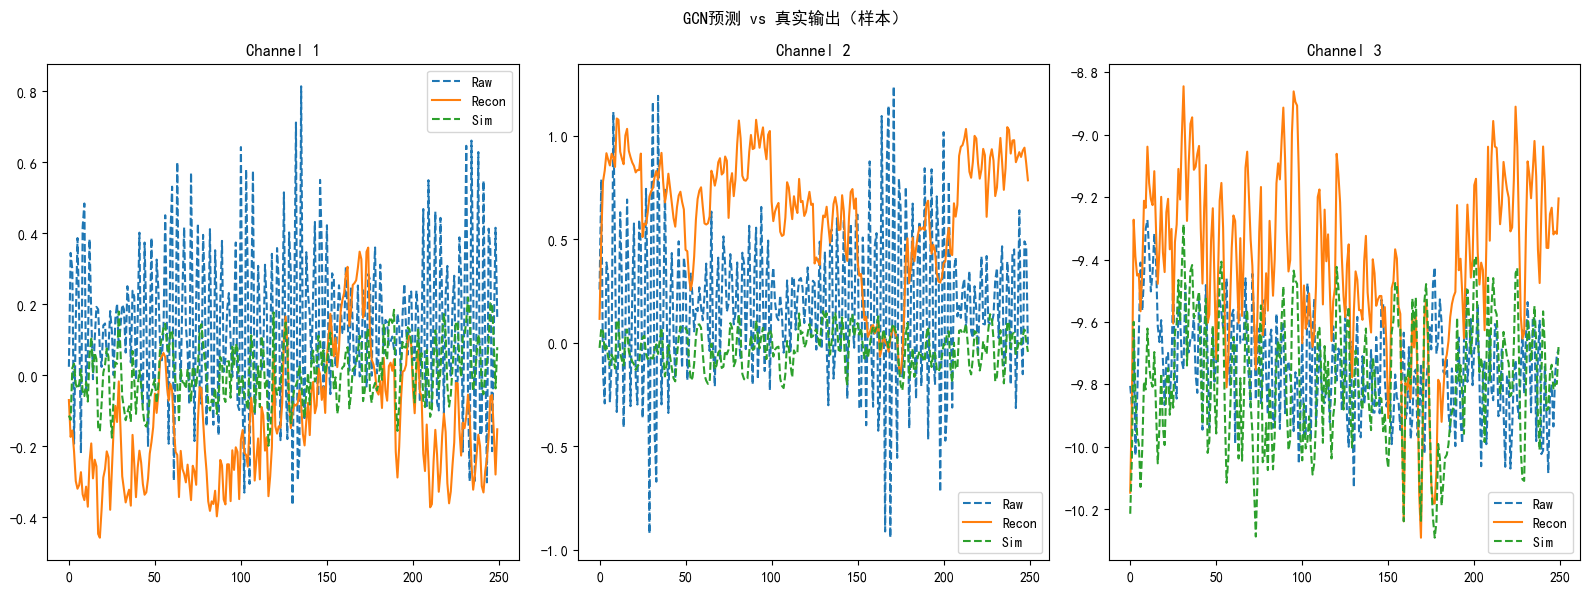

In [71]:
def reverse_data_to_model(compensated_dataset_x, sequence_length, step_size):
    compensated_dataset_x = compensated_dataset_x.cpu().numpy() 
    num_sequences, W, feature_num = compensated_dataset_x.shape  
    
    original_length = (num_sequences - 1) * step_size + sequence_length
    
    recovered_data = np.zeros((original_length, feature_num), dtype=np.float32)
    counts = np.zeros((original_length, feature_num), dtype=np.float32)  
    
    for seq_idx in range(num_sequences):
        start_idx = seq_idx * step_size  
        end_idx = start_idx + sequence_length
        seq = compensated_dataset_x[seq_idx]
        
        recovered_data[start_idx:end_idx] += seq
        counts[start_idx:end_idx] += 1
    
    # 5. 核心修改：仅重叠部分（counts > 1）除以计数，无重叠部分（counts == 1）不操作
    # counts == 0：未被任何序列覆盖，保持0；counts == 1：无重叠，保留累加值；counts > 1：重叠，取平均
    mask_overlap = counts > 1  # 重叠位置的掩码（True表示重叠）
    recovered_data[mask_overlap] = recovered_data[mask_overlap] / counts[mask_overlap]

    return recovered_data

recovered_sim_data = reverse_data_to_model(
    compensated_dataset_x=compensated_dataset_x,
    sequence_length=window_size,
    step_size=step_size
) 

recovered_raw_data = reverse_data_to_model(
    compensated_dataset_x=raw_dataset_y,
    sequence_length=window_size,
    step_size=step_size
)

recovered_raw_sim_data = reverse_data_to_model(
    compensated_dataset_x=origin_dataset_x,
    sequence_length=window_size,
    step_size=step_size
)

print(f'recovered_sim_data shape: {recovered_sim_data.shape} recovered_raw_data shape: {recovered_raw_data.shape}')

plt.figure(figsize=(16, 6))
length_ = 250
for i in range(recovered_sim_data.shape[1]):
    plt.subplot(1, 3, i+1)
    plt.plot(recovered_raw_data[:length_, i], label="Raw", linestyle='--')
    plt.plot(recovered_sim_data[:length_, i], label="Recon")
    plt.plot(recovered_raw_sim_data[:length_, i], label="Sim", linestyle='--')
    plt.title(f'Channel {i+1}')
    plt.legend()
plt.suptitle("GCN预测 vs 真实输出（样本）")
plt.tight_layout()
plt.show()


In [134]:
import shutil

ReSaved = True
mode_name = 'EC_VAE_GYRO_HOVER_M3F4.pth'
folder_name = mode_name.split('.')[0]
folder_path = os.path.join(os.getcwd(), folder_name)
path = os.path.join(os.getcwd(), folder_name, mode_name)

if not os.path.exists(folder_path):
    os.makedirs(folder_path, exist_ok=True)

torch.save(vae, path)
print(f'Model Re-Saved to {path}')


Model Re-Saved to d:\Tjh\Platform\PHM\model\compare\EC_VAE_GYRO_HOVER_M3F4\EC_VAE_GYRO_HOVER_M3F4.pth
